# Анализ результатов refactored-пайплайна UnTIE

Ноутбук для анализа JSON-результатов из:
- `artifacts/results_keys_refactored.json` (EN / SciREx)
- `artifacts/results_keys_rus_refactored.json` (RU / RuSERRC)

Артефакты сохраняются в `experiments/analysis_results/`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    """Ищет корень репозитория по untie/results_analysis.py и pyproject.toml."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "untie" / "results_analysis.py").is_file() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError(
        "Не найден корень UnTIE. Откройте ноутбук из POLINA/UnTIE_project "
        "и перезапустите kernel (Kernel -> Restart)."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from untie.results_analysis import (
    STRATEGY_COLUMNS,
    add_composite_score,
    aggregate_by_strategy,
    build_strategy_groups,
    build_summary_table,
    enrich_with_metrics,
    filter_valid_rows,
    load_results,
    project_root,
    split_evaluable_rows,
    strategy_applicability_summary,
)

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

ARTIFACTS_DIR = project_root() / "artifacts"
OUTPUT_DIR = project_root() / "experiments" / "analysis_results"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "en": ARTIFACTS_DIR / "results_keys_refactored.json",
    "ru": ARTIFACTS_DIR / "results_keys_rus_refactored.json",
}

COLORS = {"improved": "#2ecc71", "unchanged": "#f39c12", "worsened": "#e74c3c"}
plt.style.use("default")
if HAS_SEABORN:
    sns.set_palette("husl")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /home/aiserver/POLINA/UnTIE_project
OUTPUT_DIR: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results


In [2]:
def analyze_dataset(lang: str, path: Path) -> dict:
    raw = load_results(path)
    valid, invalid = filter_valid_rows(raw)
    analysis_df = enrich_with_metrics(valid)
    evaluable_df, degenerate_df = split_evaluable_rows(analysis_df)
    applicability = strategy_applicability_summary(analysis_df)

    groups = build_strategy_groups(analysis_df)
    summary = add_composite_score(build_summary_table(groups))
    evaluable_groups = build_strategy_groups(evaluable_df)
    evaluable_summary = add_composite_score(build_summary_table(evaluable_groups))

    score_stats = aggregate_by_strategy(analysis_df, "score_chunk_strategy")
    cluster_stats = aggregate_by_strategy(analysis_df, "choose_cluster_strategy")
    answer_stats = aggregate_by_strategy(analysis_df, "choose_answer_strategy")

    summary_path = OUTPUT_DIR / f"metrics_summary_{lang}.csv"
    summary.to_csv(summary_path, encoding="utf-8")
    evaluable_summary_path = OUTPUT_DIR / f"metrics_summary_evaluable_{lang}.csv"
    evaluable_summary.to_csv(evaluable_summary_path, encoding="utf-8")

    strategy_stats = pd.concat(
        {
            "score": score_stats,
            "cluster": cluster_stats,
            "answer": answer_stats,
        },
        names=["strategy_type", "strategy_name"],
    )
    strategy_stats.to_csv(OUTPUT_DIR / f"strategy_stats_{lang}.csv", encoding="utf-8")

    return {
        "lang": lang,
        "path": path,
        "raw": raw,
        "valid": valid,
        "invalid": invalid,
        "analysis_df": analysis_df,
        "evaluable_df": evaluable_df,
        "degenerate_df": degenerate_df,
        "applicability": applicability,
        "groups": groups,
        "summary": summary,
        "evaluable_summary": evaluable_summary,
        "score_stats": score_stats,
        "cluster_stats": cluster_stats,
        "answer_stats": answer_stats,
        "summary_path": summary_path,
        "evaluable_summary_path": evaluable_summary_path,
    }


results = {}
for lang, path in DATASETS.items():
    if not path.exists():
        print(f"⚠ Пропуск {lang}: файл не найден — {path}")
        continue
    results[lang] = analyze_dataset(lang, path)
    r = results[lang]
    app = r["applicability"]
    print(f"\n=== {lang.upper()} ===")
    print(f"Всего строк: {len(r['raw'])}, валидных: {len(r['valid'])}, отфильтровано: {len(r['invalid'])}")
    print(f"Документов: {r['valid']['doc_id'].nunique()}, групп стратегий: {len(r['groups'])}")
    print(
        "Сравнение применимо: "
        f"{app['evaluable_documents']}/{app['total_documents']} документов "
        f"({app['evaluable_documents_pct']:.1f}%)"
    )
    print(f"Общая сводка: {r['summary_path']}")
    print(f"Evaluable-сводка: {r['evaluable_summary_path']}")



=== EN ===
Всего строк: 7456, валидных: 7425, отфильтровано: 31
Документов: 275, групп стратегий: 27
Сравнение применимо: 275/275 документов (100.0%)
Общая сводка: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/metrics_summary_en.csv
Evaluable-сводка: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/metrics_summary_evaluable_en.csv

=== RU ===
Всего строк: 4224, валидных: 4212, отфильтровано: 12
Документов: 156, групп стратегий: 27
Сравнение применимо: 128/156 документов (82.1%)
Общая сводка: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/metrics_summary_ru.csv
Evaluable-сводка: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/metrics_summary_evaluable_ru.csv


In [3]:
for lang, r in results.items():
    print(f"\n{'=' * 70}")
    print(f"ТОП-5 комбинаций ({lang.upper()}) по полному улучшению")
    print('=' * 70)
    display_cols = [
        "overall_improved_pct",
        "overall_worsened_pct",
        "cosine_improved_pct",
        "lev_improved_pct",
        "composite_score",
    ]
    print(r["summary"][display_cols].head())

    best = r["summary"].iloc[0]
    best_name = r["summary"].index[0]
    print(f"\nЛучшая комбинация: {best_name}")
    print(f"  Полное улучшение: {best['overall_improved_pct']:.1f}%")
    print(f"  Composite score: {best['composite_score']:.2f}")

    if not r["evaluable_summary"].empty:
        print(f"\nТОП-5 комбинаций ({lang.upper()}) на evaluable-подмножестве")
        print(r["evaluable_summary"][display_cols].head())
    else:
        print("\nEvaluable-подмножество пусто: стратегии не выбирали между разными ответами.")



ТОП-5 комбинаций (EN) по полному улучшению
                                                    overall_improved_pct  \
strategy_combo                                                             
equal_weight_score_diff_weighted_score_combined...             53.454545   
equal_weight_score_diff_weighted_score_highest_...             53.454545   
only_score_diff_weighted_score_highest_chunk_score             53.090909   
only_score_diff_weighted_score_combined_score                  53.090909   
only_weight_weighted_score_combined_score                      53.090909   

                                                    overall_worsened_pct  \
strategy_combo                                                             
equal_weight_score_diff_weighted_score_combined...              3.272727   
equal_weight_score_diff_weighted_score_highest_...              3.272727   
only_score_diff_weighted_score_highest_chunk_score              3.636364   
only_score_diff_weighted_score_combined_sco

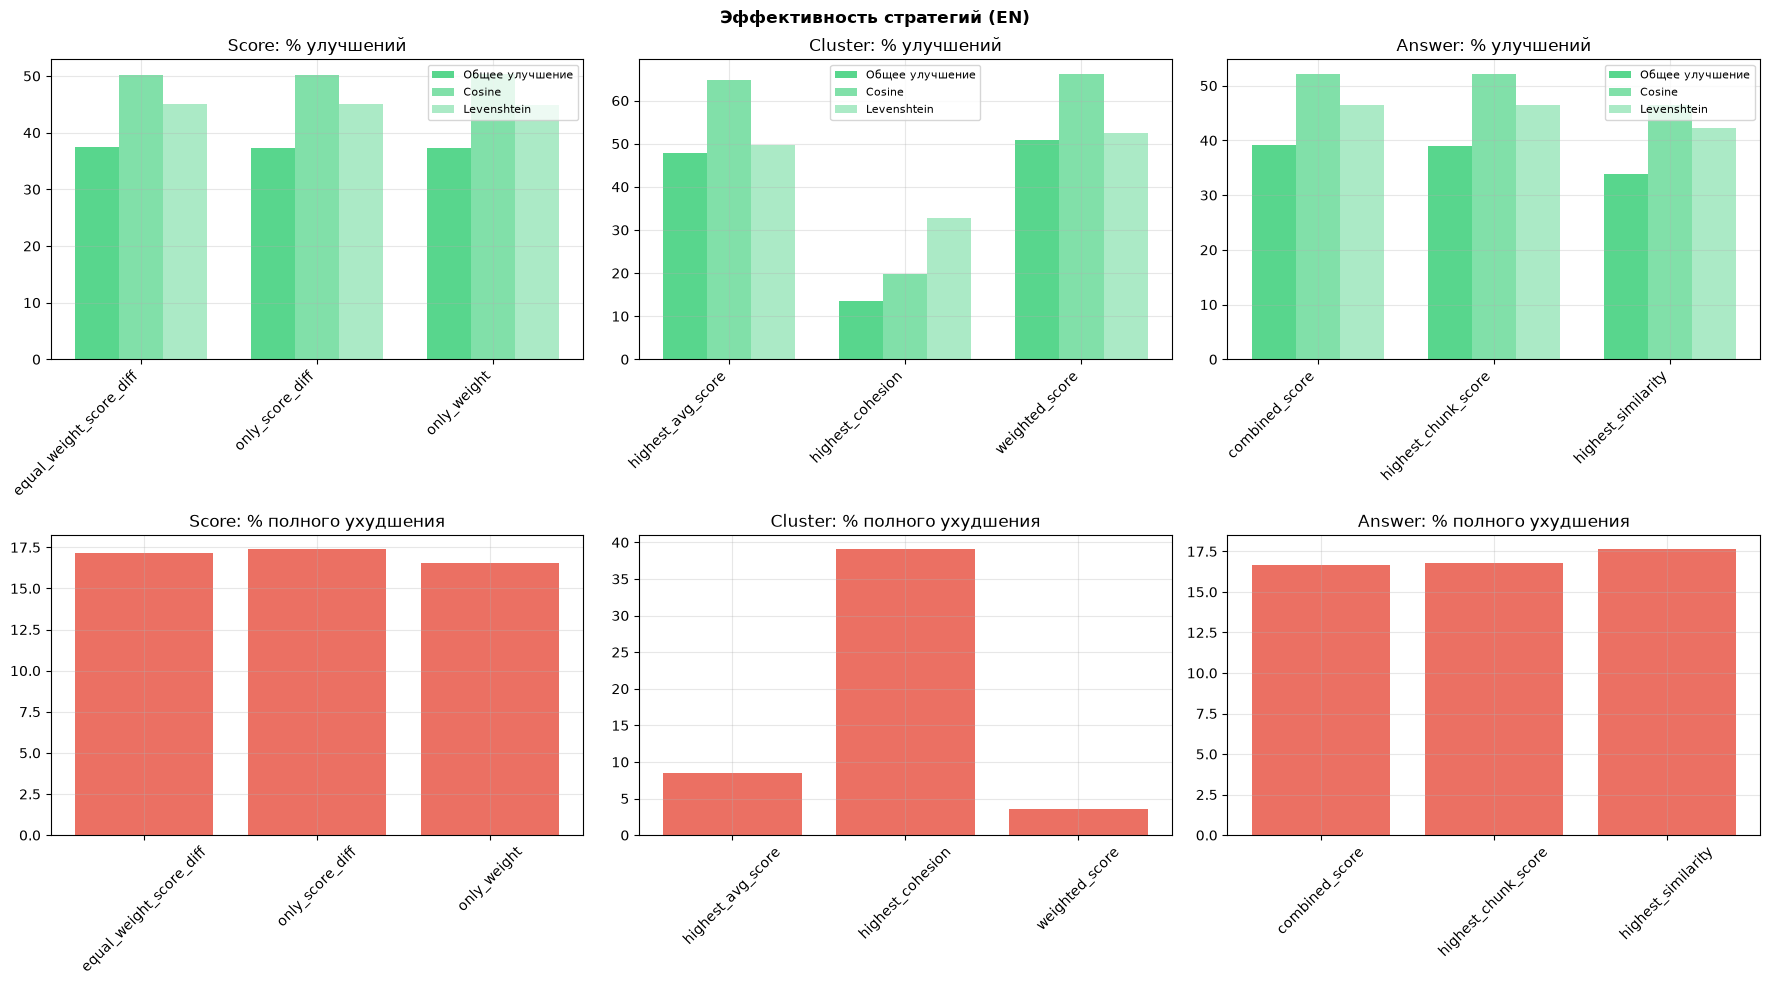

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/figures/strategy_bars_en.png


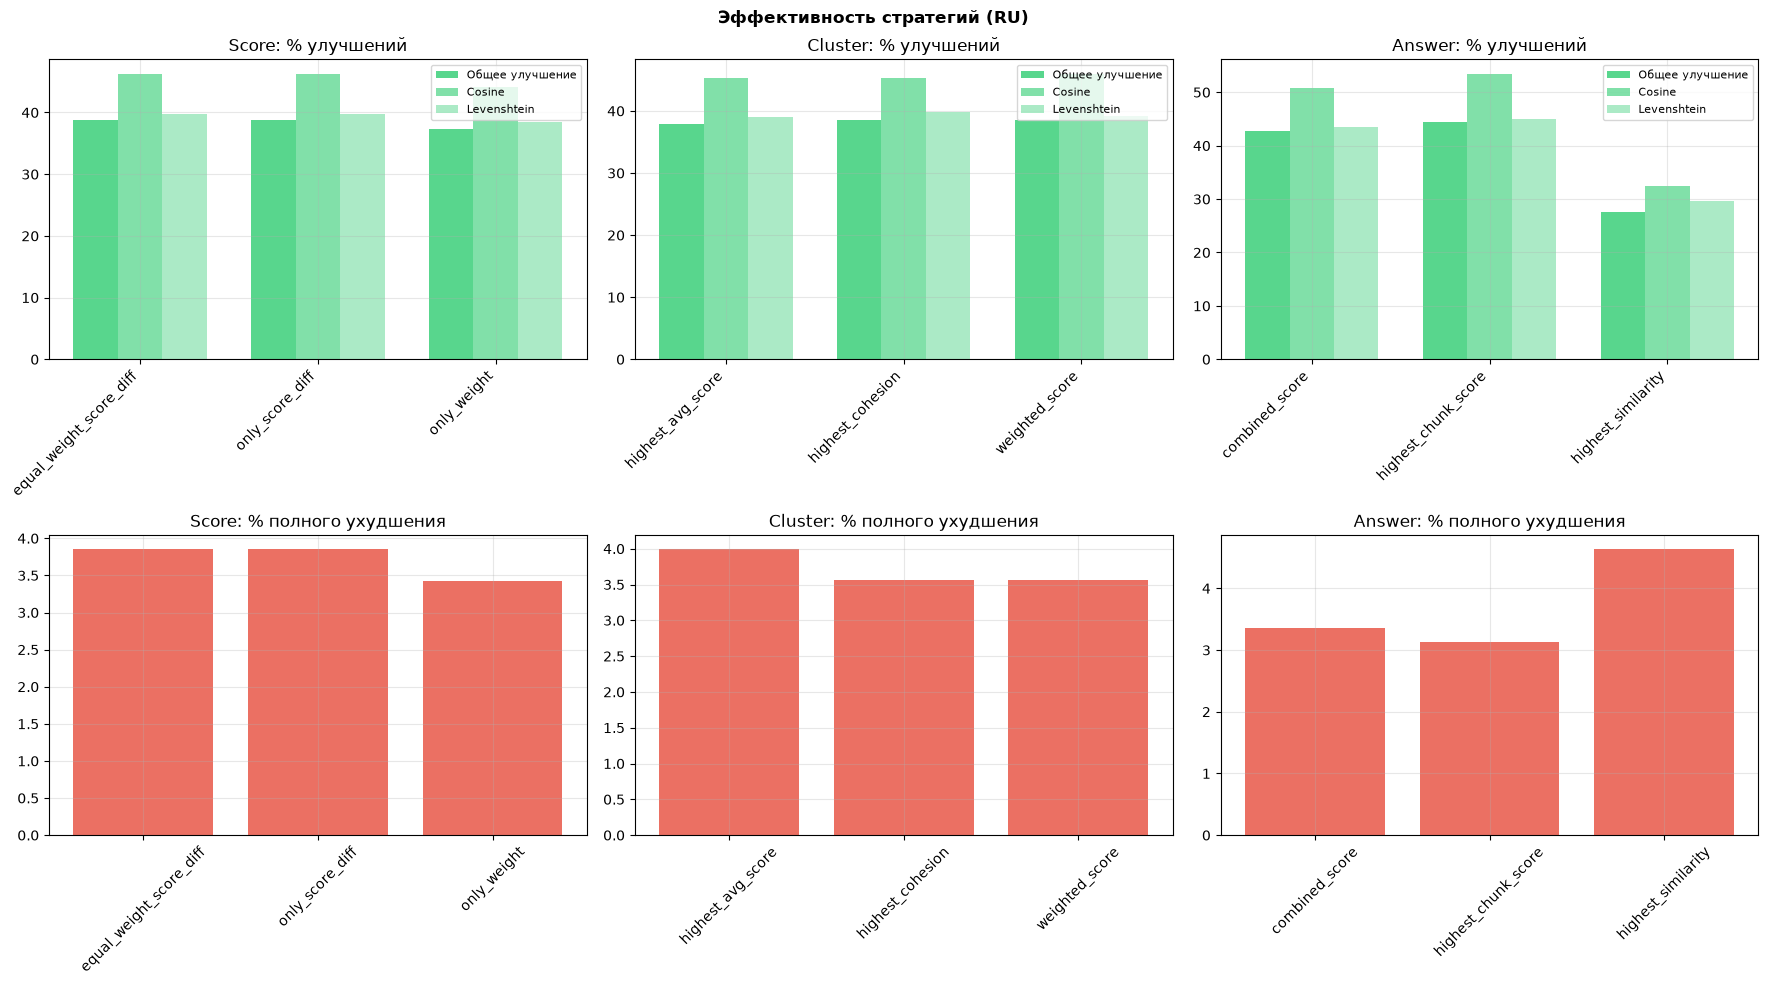

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/figures/strategy_bars_ru.png


In [4]:
def plot_strategy_bars(lang: str, r: dict) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    width = 0.25

    for col_idx, (label, stats) in enumerate(
        [
            ("Score", r["score_stats"]),
            ("Cluster", r["cluster_stats"]),
            ("Answer", r["answer_stats"]),
        ]
    ):
        improvement = stats[
            ["overall_improved_pct", "cosine_improved_pct", "lev_improved_pct"]
        ]
        x_pos = np.arange(len(improvement))
        axes[0, col_idx].bar(
            x_pos - width,
            improvement["overall_improved_pct"],
            width,
            label="Общее улучшение",
            color=COLORS["improved"],
            alpha=0.8,
        )
        axes[0, col_idx].bar(
            x_pos,
            improvement["cosine_improved_pct"],
            width,
            label="Cosine",
            color=COLORS["improved"],
            alpha=0.6,
        )
        axes[0, col_idx].bar(
            x_pos + width,
            improvement["lev_improved_pct"],
            width,
            label="Levenshtein",
            color=COLORS["improved"],
            alpha=0.4,
        )
        axes[0, col_idx].set_title(f"{label}: % улучшений")
        axes[0, col_idx].set_xticks(x_pos)
        axes[0, col_idx].set_xticklabels(improvement.index, rotation=45, ha="right")
        axes[0, col_idx].legend(fontsize=8)
        axes[0, col_idx].grid(True, alpha=0.3)

        axes[1, col_idx].bar(
            stats.index,
            stats["overall_worsened_pct"],
            color=COLORS["worsened"],
            alpha=0.8,
        )
        axes[1, col_idx].set_title(f"{label}: % полного ухудшения")
        axes[1, col_idx].tick_params(axis="x", rotation=45)
        axes[1, col_idx].grid(True, alpha=0.3)

    fig.suptitle(f"Эффективность стратегий ({lang.upper()})", fontweight="bold")
    fig.tight_layout()
    out = FIGURES_DIR / f"strategy_bars_{lang}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {out}")


for lang, r in results.items():
    plot_strategy_bars(lang, r)


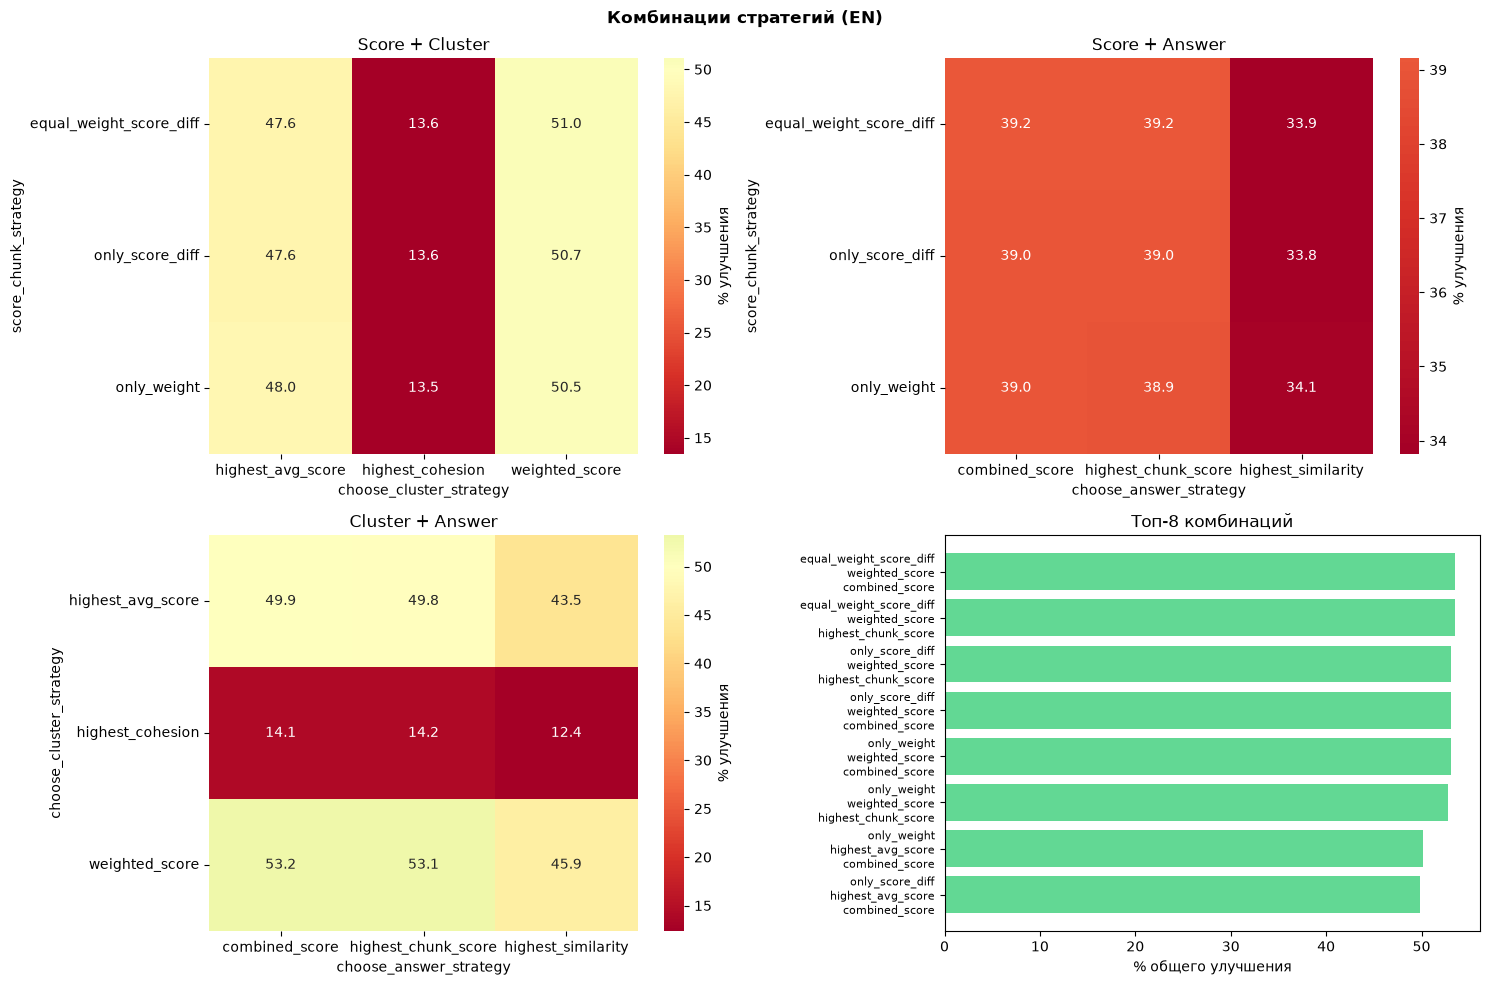

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/figures/combos_en.png


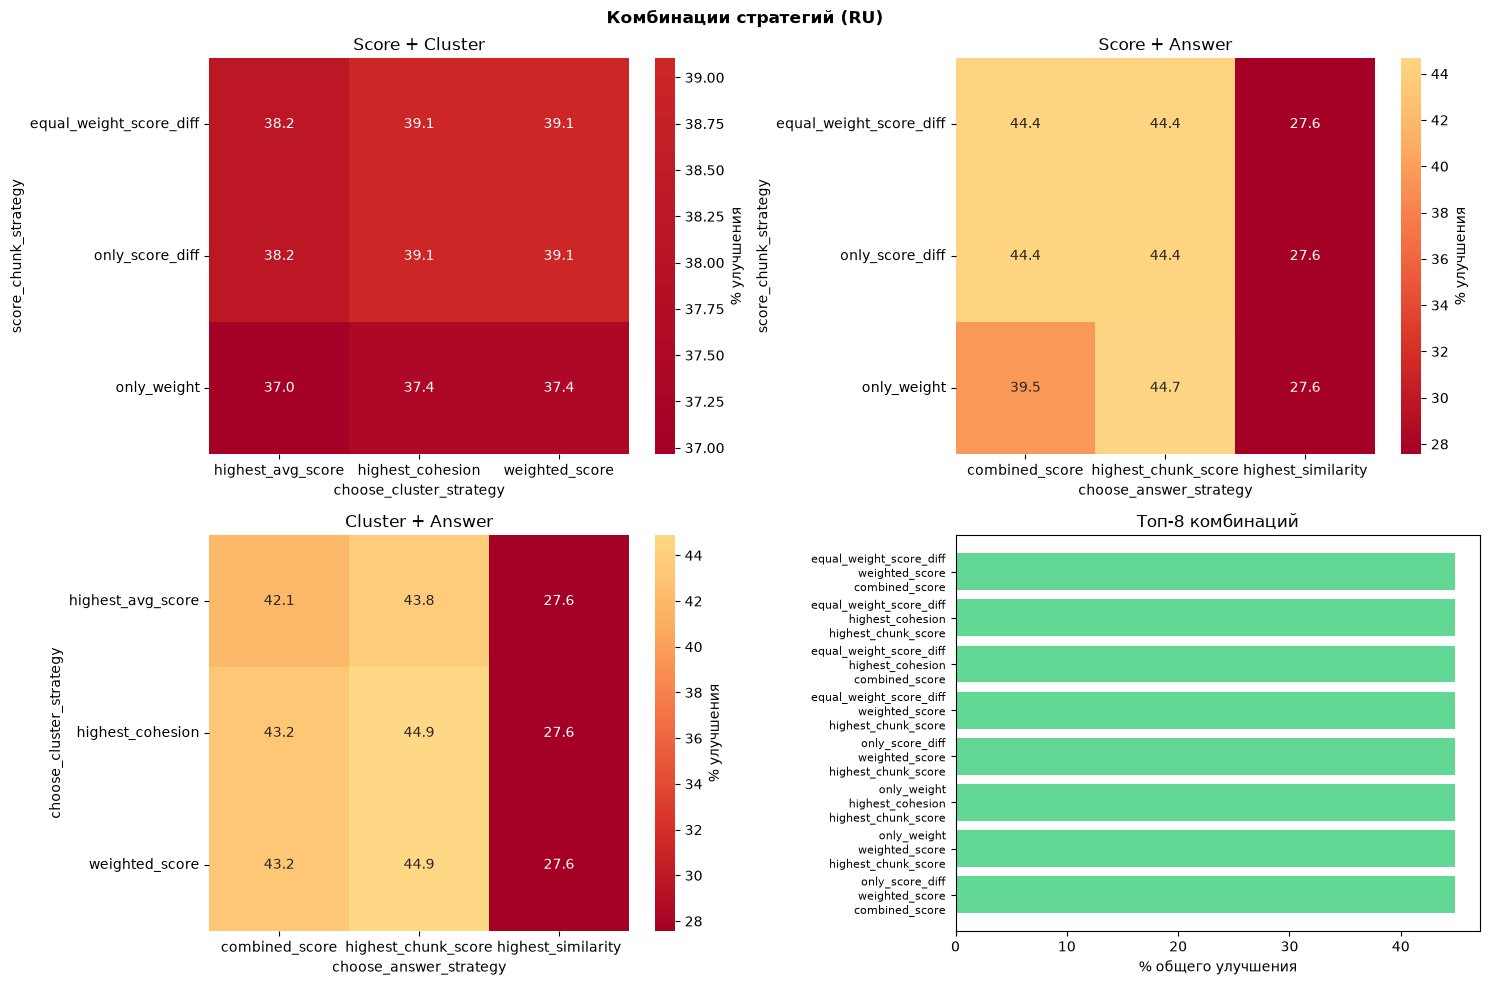

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/figures/combos_ru.png


In [5]:
def plot_heatmaps_and_top_combos(lang: str, r: dict) -> None:
    df = r["analysis_df"]
    combo_stats = (
        df.groupby(list(STRATEGY_COLUMNS))
        .agg(
            overall_improved_pct=("overall_improved", lambda s: s.mean() * 100),
            count=("doc_id", "count"),
        )
        .sort_values("overall_improved_pct", ascending=False)
    )

    fig = plt.figure(figsize=(15, 10))

    if HAS_SEABORN:
        ax1 = plt.subplot(2, 2, 1)
        score_cluster = (
            df.groupby(["score_chunk_strategy", "choose_cluster_strategy"])["overall_improved"]
            .mean()
            .unstack()
            * 100
        )
        sns.heatmap(
            score_cluster,
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            center=50,
            cbar_kws={"label": "% улучшения"},
            ax=ax1,
        )
        ax1.set_title("Score + Cluster")

        ax2 = plt.subplot(2, 2, 2)
        score_answer = (
            df.groupby(["score_chunk_strategy", "choose_answer_strategy"])["overall_improved"]
            .mean()
            .unstack()
            * 100
        )
        sns.heatmap(
            score_answer,
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            center=50,
            cbar_kws={"label": "% улучшения"},
            ax=ax2,
        )
        ax2.set_title("Score + Answer")

        ax3 = plt.subplot(2, 2, 3)
        cluster_answer = (
            df.groupby(["choose_cluster_strategy", "choose_answer_strategy"])["overall_improved"]
            .mean()
            .unstack()
            * 100
        )
        sns.heatmap(
            cluster_answer,
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            center=50,
            cbar_kws={"label": "% улучшения"},
            ax=ax3,
        )
        ax3.set_title("Cluster + Answer")
    else:
        for i, title in enumerate(["Score + Cluster", "Score + Answer", "Cluster + Answer"], start=1):
            plt.subplot(2, 2, i)
            plt.text(0.5, 0.5, "Установите seaborn для heatmap", ha="center")
            plt.title(title)
            plt.axis("off")

    ax4 = plt.subplot(2, 2, 4)
    top = combo_stats.head(8)
    labels = ["\n".join(map(str, idx)) for idx in top.index]
    ax4.barh(range(len(top)), top["overall_improved_pct"], color=COLORS["improved"], alpha=0.75)
    ax4.set_yticks(range(len(top)))
    ax4.set_yticklabels(labels, fontsize=8)
    ax4.set_xlabel("% общего улучшения")
    ax4.set_title("Топ-8 комбинаций")
    ax4.invert_yaxis()

    fig.suptitle(f"Комбинации стратегий ({lang.upper()})", fontweight="bold")
    fig.tight_layout()
    out = FIGURES_DIR / f"combos_{lang}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {out}")


for lang, r in results.items():
    plot_heatmaps_and_top_combos(lang, r)


In [7]:
if len(results) == 2:
    en_summary = results["en"]["summary"][["overall_improved_pct", "composite_score"]]
    ru_summary = results["ru"]["summary"][["overall_improved_pct", "composite_score"]]
    compare = en_summary.join(
        ru_summary,
        lsuffix="_en",
        rsuffix="_ru",
        how="inner",
    )
    compare["delta_overall_improved_pct"] = (
        compare["overall_improved_pct_ru"] - compare["overall_improved_pct_en"]
    )
    compare["mean_overall_improved_pct"] = (
            (compare["overall_improved_pct_ru"] + compare["overall_improved_pct_en"])/2
        )
    compare = compare.sort_values("mean_overall_improved_pct", ascending=False)
    compare_path = OUTPUT_DIR / "en_ru_strategy_comparison.csv"
    compare.to_csv(compare_path, encoding="utf-8")
    print("Сравнение EN vs RU по комбинациям стратегий:")
    # display(compare.head(10))
    display(compare)
    print(f"\nСохранено: {compare_path}")
else:
    print("Сравнение EN/RU пропущено: загружен неполный набор файлов.")


Сравнение EN vs RU по комбинациям стратегий:


,overall_improved_pct_en,composite_score_en,overall_improved_pct_ru,composite_score_ru,delta_overall_improved_pct,mean_overall_improved_pct
strategy_combo,,,,,,
equal_weight_score_diff_weighted_score_combined_score,53.454545,57.818182,44.871795,46.923077,-8.582751,49.163170
equal_weight_score_diff_weighted_score_highest_chunk_score,53.454545,57.818182,44.871795,46.923077,-8.582751,49.163170
only_score_diff_weighted_score_highest_chunk_score,53.090909,57.381818,44.871795,46.923077,-8.219114,48.981352
only_score_diff_weighted_score_combined_score,53.090909,57.381818,44.871795,46.923077,-8.219114,48.981352
only_weight_weighted_score_highest_chunk_score,52.727273,57.381818,44.871795,47.243590,-7.855478,48.799534
only_weight_highest_avg_score_highest_chunk_score,49.818182,54.145455,44.230769,46.794872,-5.587413,47.024476
equal_weight_score_diff_highest_avg_score_highest_chunk_score,49.818182,53.709091,43.589744,45.705128,-6.228438,46.703963
only_score_diff_highest_avg_score_highest_chunk_score,49.818182,53.636364,43.589744,45.705128,-6.228438,46.703963
equal_weight_score_diff_highest_avg_score_combined_score,49.818182,53.709091,43.589744,45.705128,-6.228438,46.703963



Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/en_ru_strategy_comparison.csv


In [ ]:
# Непараметрические тесты (как в legacy-ноутбуке)
try:
    from scipy.stats import friedmanchisquare, shapiro, wilcoxon
    from statsmodels.stats.multitest import multipletests

    HAS_STATS = True
except ImportError:
    HAS_STATS = False
    print("Для статистических тестов установите: pip install scipy statsmodels scikit-posthocs")

if HAS_STATS:
    stat_rows = []
    for lang, r in results.items():
        cosine_diff_data = {
            name: group_df["cosine_sim_diff"].tolist()
            for name, group_df in r["groups"].items()
        }
        cosine_diff_df = pd.DataFrame(cosine_diff_data)
        friedman_data = [cosine_diff_df[col].dropna() for col in cosine_diff_df.columns]
        min_len = min(len(data) for data in friedman_data)
        friedman_balanced = [data.iloc[:min_len].values for data in friedman_data]
        friedman_stat, friedman_p = friedmanchisquare(*friedman_balanced)

        mean_improvements = cosine_diff_df.mean().sort_values(ascending=False)
        best_strategy = mean_improvements.index[0]
        comparisons = []
        for strategy in cosine_diff_df.columns:
            if strategy == best_strategy:
                continue
            stat, p_value = wilcoxon(
                cosine_diff_df[best_strategy].dropna(),
                cosine_diff_df[strategy].dropna(),
            )
            comparisons.append(
                {
                    "lang": lang,
                    "comparison": f"{best_strategy} vs {strategy}",
                    "statistic": stat,
                    "p_value": p_value,
                    "mean_diff": mean_improvements[best_strategy] - mean_improvements[strategy],
                }
            )

        corrected = multipletests([c["p_value"] for c in comparisons], method="fdr_bh")[1]
        for comp, corr_p in zip(comparisons, corrected):
            comp["corrected_p_value"] = corr_p
            comp["significant"] = corr_p < 0.05
            stat_rows.append(
                {
                    "lang": lang,
                    "test": "wilcoxon_vs_best",
                    **comp,
                }
            )

        stat_rows.append(
            {
                "lang": lang,
                "test": "friedman",
                "comparison": "all_strategies",
                "statistic": friedman_stat,
                "p_value": friedman_p,
                "mean_diff": np.nan,
                "corrected_p_value": friedman_p,
                "significant": friedman_p < 0.05,
            }
        )

        print(f"\n{lang.upper()}: Friedman p={friedman_p:.6f}, лучшая стратегия: {best_strategy}")

    stat_df = pd.DataFrame(stat_rows)
    stat_path = OUTPUT_DIR / "statistical_tests.csv"
    stat_df.to_csv(stat_path, index=False, encoding="utf-8")
    print(f"\nСтатистика сохранена: {stat_path}")


## Примечания

- Метрики в refactored JSON уже хранятся как dict (`base_metrics`, `corrected_metrics`), legacy-строки тоже поддерживаются.
- Строки с `--No valid answers--` в `final_answer` или в колонках стратегий исключаются из анализа.
- RU-строки с `strategy_applicable=True` анализируются отдельно как evaluable-подмножество.
- Для полного прогона убедитесь, что JSON-файлы в `artifacts/` актуальны.